In [4]:
import os
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(os.path.exists(os.path.join(base_dir, "GivenResources")))


True


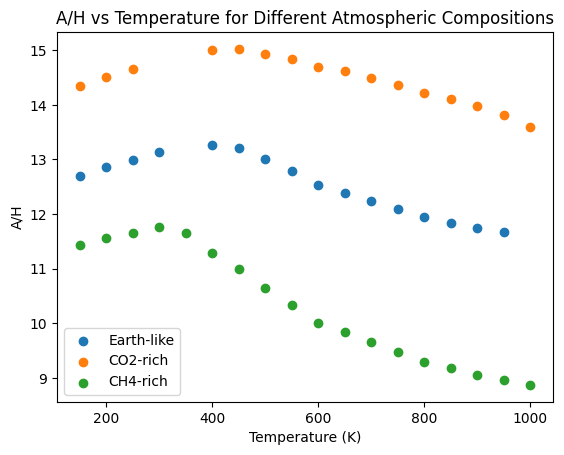

In [ ]:
import numpy as np
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import csv

# Define the atmospheric compositions you want to investigate
compositions = [
    {'name': 'Earth-like', 'logX': {'h2o': -1.1, 'ch4': -1.74, 'co': -2.0, 'co2': -1.7}},
    {'name': 'CO2-rich',  'logX': {'h2o': -2.0, 'ch4': -2.5, 'co': -2.0, 'co2': -1.0}},
    {'name': 'CH4-rich',  'logX': {'h2o': -1.5, 'ch4': -1.0, 'co': -2.0, 'co2': -2.0}}
]

# Load planetary data
with open("/Users/evely/Group-Studies---Exoplanets/Code/Data/GJ 1214 b change in temp.csv", newline="") as f:
    reader = csv.reader(f)
    header = next(reader)
    temp_idx = header.index("pl_Teq")
    data = []
    planetNames = []
    temp_values = []
    for row in reader:
        row = [item.strip() for item in row]
        if len(row) == 0:
            continue
        name, *nums = row
        conv = [float(item) if item != "" else np.nan for item in nums]
        data.append(conv)
        planetNames.append(name)
        temp = float(nums[temp_idx - 1]) if nums[temp_idx - 1] != "" else np.nan
        temp_values.append(temp)
    planetaryParameters = np.array(data, dtype=float)

# Load cross-section data once
xsec_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
lam_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6
P_h2o = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy'))
T_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

xsec_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
lam_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6
P_co2 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy'))
T_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

xsec_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
lam_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6
P_ch4 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy'))
T_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

xsec_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
lam_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6
P_co = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy'))
T_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

xsec_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
lam_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')
xsec_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
lam_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')

# Loop over compositions
for comp in compositions:
    A_H_Array = []

    for rowCount in range(len(planetaryParameters)):
        Rp = planetaryParameters[rowCount][3] * const.R_earth.value
        Tp = planetaryParameters[rowCount][39]
        Rs = planetaryParameters[rowCount][14] * const.R_sun.value
        gp = planetaryParameters[rowCount][37] / 100.0
        Pcloud = 100 * 1.0e5
        Pref = 0.01 * 1.0e5

        P = np.logspace(2.0,-9,200) * 1.0e5
        T = Tp*np.ones_like(P)
        n = P/(sc.k*T)

        r = np.zeros_like(P)
        g = np.zeros_like(P)
        i_Rp = np.argmin(np.abs(P-Pref))
        r[i_Rp] = Rp
        g[i_Rp] = gp

        # Compose atmosphere
        logX = comp['logX'].copy()
        mmw = {'h2o': 18.0, 'ch4': 16.0, 'co': 28.0, 'co2': 44.0, 'h2': 2.0, 'he': 4.0}
        X_rest = np.sum([10.0**logX[key] for key in logX])
        X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
        X_He = 0.17 * X_H2
        logX['h2'] = np.log10(X_H2)
        logX['he'] = np.log10(X_He)

        mu = 0.0
        for mol in logX.keys():
            mu += 10.0**logX[mol]*mmw[mol]
        mu *= sc.u

        # Compute radius profile
        for i in range(i_Rp + 1, len(P)):
            g[i] = g[i_Rp] * r[i_Rp]**2 / r[i-1]**2
            r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 
        for i in range(i_Rp-1, -1, -1):
            g[i] = g[i_Rp] * r[i_Rp]**2 / r[i+1]**2
            r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

        lam = np.linspace(0.61,5.0,5000)
        lamlam, PP = np.meshgrid(lam, P, indexing="ij")

        # Interpolators
        interp_h2o = RegularGridInterpolator((lam_h2o,P_h2o,T_h2o), xsec_h2o, method='linear', bounds_error=False, fill_value=None)
        interp_co2 = RegularGridInterpolator((lam_co2,P_co2,T_co2), xsec_co2, method='linear', bounds_error=False, fill_value=None)
        interp_ch4 = RegularGridInterpolator((lam_ch4,P_ch4,T_ch4), xsec_ch4, method='linear', bounds_error=False, fill_value=None)
        interp_co = RegularGridInterpolator((lam_co,P_co,T_co), xsec_co, method='linear', bounds_error=False, fill_value=None)

        # Clip temperature to valid grid ranges
        T0_h2o = np.clip(T[0], T_h2o.min(), T_h2o.max())
        T0_co2 = np.clip(T[0], T_co2.min(), T_co2.max())
        T0_ch4 = np.clip(T[0], T_ch4.min(), T_ch4.max())
        T0_co = np.clip(T[0], T_co.min(), T_co.max())

        # Flatten meshgrid for interpolation
        points_h2o = np.vstack([lamlam.ravel(), PP.ravel(), T0_h2o*np.ones(lamlam.size)]).T
        points_co2 = np.vstack([lamlam.ravel(), PP.ravel(), T0_co2*np.ones(lamlam.size)]).T
        points_ch4 = np.vstack([lamlam.ravel(), PP.ravel(), T0_ch4*np.ones(lamlam.size)]).T
        points_co = np.vstack([lamlam.ravel(), PP.ravel(), T0_co*np.ones(lamlam.size)]).T

        log_xsec_dict = {
            'h2o': interp_h2o(points_h2o).reshape(lamlam.shape),
            'co2': interp_co2(points_co2).reshape(lamlam.shape),
            'ch4': interp_ch4(points_ch4).reshape(lamlam.shape),
            'co': interp_co(points_co).reshape(lamlam.shape)
        }
        log_cia_dict = {'h2h2': np.interp(lam, lam_h2h2, xsec_h2h2),
                        'heh2': np.interp(lam, lam_heh2, xsec_heh2)}

        # Compute opacity and transmission
        sum_nsigma = np.zeros((len(lam), len(P)))
        for mol in log_xsec_dict:
            sum_nsigma += n[np.newaxis,:]*10.0**logX[mol]*10.0**log_xsec_dict[mol]
        sum_nsigma += n[np.newaxis,:]**2*10.0**logX['h2']**2*10.0**log_cia_dict['h2h2'][:,np.newaxis]
        sum_nsigma += n[np.newaxis,:]**2*10.0**logX['he']*10.0**logX['h2']*10.0**log_cia_dict['heh2'][:,np.newaxis]

        integral_gt_Rp = np.zeros(len(lam))
        integral_lt_Rp = np.zeros(len(lam))
        exptau = np.zeros((len(P), len(lam)))
        transit_depth = np.zeros(len(lam))

        opacity = sum_nsigma
        for i in range(len(r)-1):
            s_tot = np.sqrt(r[i:]**2 - r[i]**2)
            ds = s_tot[1:] - s_tot[:-1]
            tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:], axis=-1)
            if P[i] > Pcloud:
                tau_tot += 1000.0
            exptau[i,:] = np.exp(-tau_tot) + 1.0e-250

        for i in range(len(r)-1):
            if r[i] >= Rp:
                integral_gt_Rp += 0.5*((r[i]*(1-exptau[i,:]) + r[i+1]*(1-exptau[i+1,:]))*(r[i+1]-r[i]))
            if r[i] < Rp:
                integral_lt_Rp += 0.5*((r[i]*exptau[i,:] + r[i+1]*exptau[i+1,:])*(r[i+1]-r[i]))

        transit_depth[:] = (Rp**2 + 2.0*integral_gt_Rp - 2.0*integral_lt_Rp)/(Rs**2)

        # Extract feature height
        left_mask = (lam >= 4.1) & (lam <= 4.15)
        left_val = np.mean(transit_depth[left_mask])
        peak_mask = (lam >= 4.25) & (lam <= 4.28)
        peak_val = np.mean(transit_depth[peak_mask])
        feature_height_ratio = peak_val - left_val

        mu = mu/sc.u
        scale_height = (sc.k*Tp)/(mu*gp*sc.m_p)
        A_H = feature_height_ratio*(Rs**2)/(2*scale_height*Rp)
        A_H_Array.append(A_H)

    plt.scatter(temp_values, A_H_Array, marker='o', label=comp['name'])

plt.xlabel('Temperature (K)')
plt.ylabel('A/H')
plt.title('A/H vs Temperature for Different Atmospheric Compositions')
plt.legend()
plt.show()


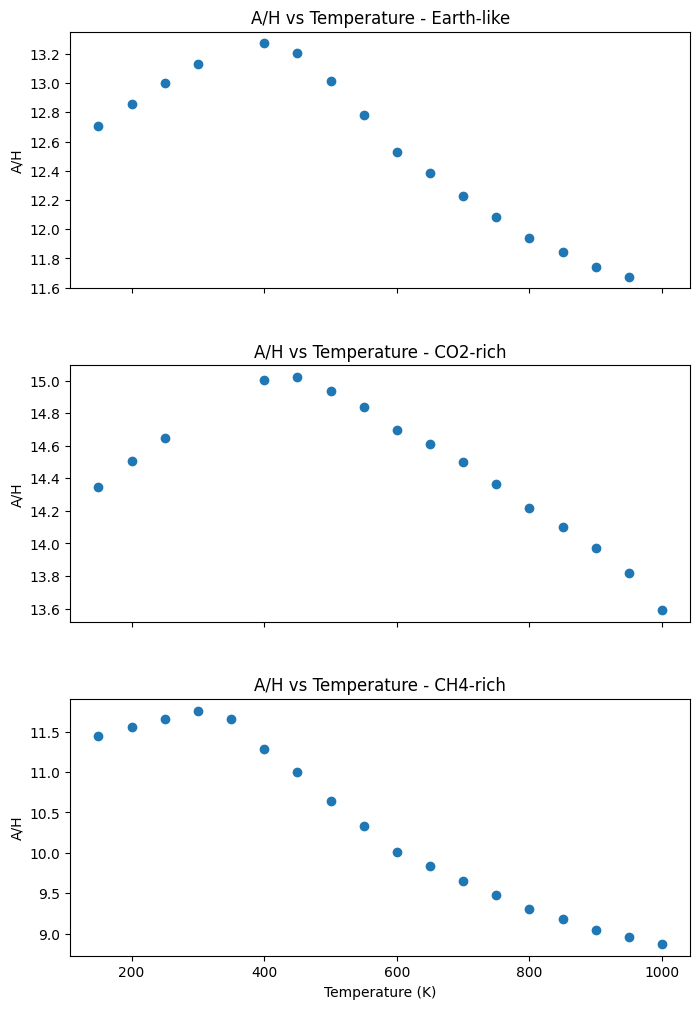

In [24]:
import numpy as np
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import csv

# Define compositions
compositions = [
    {'name': 'Earth-like', 'logX': {'h2o': -1.1, 'ch4': -1.74, 'co': -2.0, 'co2': -1.7}},
    {'name': 'CO2-rich',  'logX': {'h2o': -2.0, 'ch4': -2.5, 'co': -2.0, 'co2': -1.0}},
    {'name': 'CH4-rich',  'logX': {'h2o': -1.5, 'ch4': -1.0, 'co': -2.0, 'co2': -2.0}}
]

# Load planetary data
with open("/Users/evely/Group-Studies---Exoplanets/Code/Data/GJ 1214 b change in temp.csv", newline="") as f:
    reader = csv.reader(f)
    header = next(reader)
    temp_idx = header.index("pl_Teq")
    data = []
    planetNames = []
    temp_values = []
    for row in reader:
        row = [item.strip() for item in row]
        if len(row) == 0:
            continue
        name, *nums = row
        conv = [float(item) if item != "" else np.nan for item in nums]
        data.append(conv)
        planetNames.append(name)
        temp = float(nums[temp_idx - 1]) if nums[temp_idx - 1] != "" else np.nan
        temp_values.append(temp)
    planetaryParameters = np.array(data, dtype=float)

# Load cross-section data once
xsec_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
lam_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6
P_h2o = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy'))
T_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

xsec_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
lam_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6
P_co2 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy'))
T_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

xsec_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
lam_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6
P_ch4 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy'))
T_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

xsec_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
lam_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6
P_co = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy'))
T_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

xsec_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
lam_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')
xsec_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
lam_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')

# Create figure with 3 vertical panels
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8,12), sharex=True)
fig.subplots_adjust(hspace=0.3)

for ax, comp in zip(axes, compositions):
    A_H_Array = []

    for rowCount in range(len(planetaryParameters)):
        Rp = planetaryParameters[rowCount][3] * const.R_earth.value
        Tp = planetaryParameters[rowCount][39]
        Rs = planetaryParameters[rowCount][14] * const.R_sun.value
        gp = planetaryParameters[rowCount][37] / 100.0
        Pcloud = 100 * 1.0e5
        Pref = 0.01 * 1.0e5

        P = np.logspace(2.0,-9,200) * 1.0e5
        T = Tp*np.ones_like(P)
        n = P/(sc.k*T)

        r = np.zeros_like(P)
        g = np.zeros_like(P)
        i_Rp = np.argmin(np.abs(P-Pref))
        r[i_Rp] = Rp
        g[i_Rp] = gp

        # Compose atmosphere
        logX = comp['logX'].copy()
        mmw = {'h2o': 18.0, 'ch4': 16.0, 'co': 28.0, 'co2': 44.0, 'h2': 2.0, 'he': 4.0}
        X_rest = np.sum([10.0**logX[key] for key in logX])
        X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
        X_He = 0.17 * X_H2
        logX['h2'] = np.log10(X_H2)
        logX['he'] = np.log10(X_He)

        mu = 0.0
        for mol in logX.keys():
            mu += 10.0**logX[mol]*mmw[mol]
        mu *= sc.u

        # Compute radius profile
        for i in range(i_Rp + 1, len(P)):
            g[i] = g[i_Rp] * r[i_Rp]**2 / r[i-1]**2
            r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 
        for i in range(i_Rp-1, -1, -1):
            g[i] = g[i_Rp] * r[i_Rp]**2 / r[i+1]**2
            r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

        lam = np.linspace(0.61,5.0,5000)
        lamlam, PP = np.meshgrid(lam, P, indexing="ij")

        # Interpolators (flatten meshgrid and clip temperature)
        def interp_species(lam_grid, P_grid, T_grid, xsec_grid):
            interp = RegularGridInterpolator((lam_grid,P_grid,T_grid), xsec_grid, method='linear', bounds_error=False, fill_value=None)
            T0 = np.clip(T[0], T_grid.min(), T_grid.max())
            points = np.vstack([lamlam.ravel(), PP.ravel(), T0*np.ones(lamlam.size)]).T
            return interp(points).reshape(lamlam.shape)

        log_xsec_dict = {
            'h2o': interp_species(lam_h2o,P_h2o,T_h2o,xsec_h2o),
            'co2': interp_species(lam_co2,P_co2,T_co2,xsec_co2),
            'ch4': interp_species(lam_ch4,P_ch4,T_ch4,xsec_ch4),
            'co': interp_species(lam_co,P_co,T_co,xsec_co)
        }

        log_cia_dict = {'h2h2': np.interp(lam, lam_h2h2, xsec_h2h2),
                        'heh2': np.interp(lam, lam_heh2, xsec_heh2)}

        # Compute opacity and transmission
        sum_nsigma = np.zeros((len(lam), len(P)))
        for mol in log_xsec_dict:
            sum_nsigma += n[np.newaxis,:]*10.0**logX[mol]*10.0**log_xsec_dict[mol]
        sum_nsigma += n[np.newaxis,:]**2*10.0**logX['h2']**2*10.0**log_cia_dict['h2h2'][:,np.newaxis]
        sum_nsigma += n[np.newaxis,:]**2*10.0**logX['he']*10.0**logX['h2']*10.0**log_cia_dict['heh2'][:,np.newaxis]

        integral_gt_Rp = np.zeros(len(lam))
        integral_lt_Rp = np.zeros(len(lam))
        exptau = np.zeros((len(P), len(lam)))
        transit_depth = np.zeros(len(lam))

        opacity = sum_nsigma
        for i in range(len(r)-1):
            s_tot = np.sqrt(r[i:]**2 - r[i]**2)
            ds = s_tot[1:] - s_tot[:-1]
            tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:], axis=-1)
            if P[i] > Pcloud:
                tau_tot += 1000.0
            exptau[i,:] = np.exp(-tau_tot) + 1.0e-250

        for i in range(len(r)-1):
            if r[i] >= Rp:
                integral_gt_Rp += 0.5*((r[i]*(1-exptau[i,:]) + r[i+1]*(1-exptau[i+1,:]))*(r[i+1]-r[i]))
            if r[i] < Rp:
                integral_lt_Rp += 0.5*((r[i]*exptau[i,:] + r[i+1]*exptau[i+1,:])*(r[i+1]-r[i]))

        transit_depth[:] = (Rp**2 + 2.0*integral_gt_Rp - 2.0*integral_lt_Rp)/(Rs**2)

        # Feature height
        left_mask = (lam >= 4.1) & (lam <= 4.15)
        left_val = np.mean(transit_depth[left_mask])
        peak_mask = (lam >= 4.25) & (lam <= 4.28)
        peak_val = np.mean(transit_depth[peak_mask])
        feature_height_ratio = peak_val - left_val

        mu = mu/sc.u
        scale_height = (sc.k*Tp)/(mu*gp*sc.m_p)
        A_H = feature_height_ratio*(Rs**2)/(2*scale_height*Rp)
        A_H_Array.append(A_H)

    # Plot for this composition in its panel
    ax.scatter(temp_values, A_H_Array, marker='o', color='tab:blue')
    ax.set_ylabel('A/H')
    ax.set_title(f"A/H vs Temperature - {comp['name']}")

axes[-1].set_xlabel('Temperature (K)')
plt.show()


below is the cleaned version of Mia's spectrum code to plot AH vs changing temp using planet data from csv files

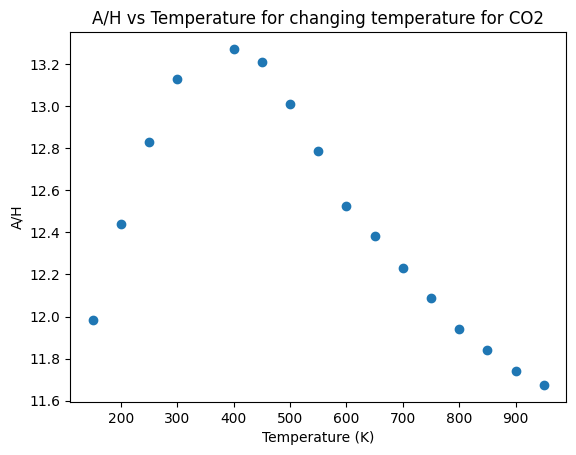

In [21]:
import numpy as np
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import csv
import pandas as pd

A_H_Array = []
feature_height_ppm_Array = []
scale_height_array = []

with open("/Users/evely/Group-Studies---Exoplanets/Code/Data/GJ 1214 b change in temp.csv", newline="") as PlanetaryParametersFile:   
    reader = csv.reader(PlanetaryParametersFile)
    header = next(reader)
    tsm_idx = header.index("pl_tsm")
    temp_idx = header.index("pl_Teq")
    data = []
    planetNames = []
    tsm_values = []
    temp_values = []
    for row in reader:
        row = [item.strip() for item in row]
        if len(row) == 0:
            continue
        name, *nums = row
        conv = [float(item) if item != "" else np.nan for item in nums]
        data.append(conv)
        planetNames.append(name)
        tsm = float(nums[tsm_idx - 1]) if nums[tsm_idx - 1] != "" else np.nan
        tsm_values.append(tsm)
        temp = float(nums[temp_idx - 1]) if nums[temp_idx - 1] != "" else np.nan
        temp_values.append(temp)
    planetaryParameters = np.array(data, dtype=float)
    
rowCount= 0
while rowCount < len(planetaryParameters):
    PName = planetNames[rowCount]
    Rp = planetaryParameters[rowCount][3] * const.R_earth.value
    Mp = planetaryParameters[rowCount][2]
    Tp = planetaryParameters[rowCount][39]
    mu = 4.88
    Pcloud = 100
    Pref = 0.01
    Rs = planetaryParameters[rowCount][14] * const.R_sun.value
    Pcloud *= 1.0e5
    Pref *= 1.0e5
    mu *= sc.u

    xsec_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
    lam_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6
    P_h2o = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy'))
    T_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

    xsec_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
    lam_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6
    P_co2 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy'))
    T_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

    xsec_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
    lam_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6
    P_ch4 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy'))
    T_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

    xsec_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
    lam_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6
    P_co = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy'))
    T_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

    xsec_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
    lam_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

    xsec_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
    lam_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')

    P = np.logspace(2.0,-9,200) * 1.0e5
    T = Tp*np.ones_like(P)
    n = P/(sc.k*T)
    rho = mu*n
    gp = planetaryParameters[rowCount][37] / 100.0
    r = np.zeros_like(P)
    g = np.zeros_like(P)
    i_Rp = np.argmin(np.abs(P-Pref))
    r[i_Rp] = Rp
    g[i_Rp] = gp

    logX = {'h2o': -1.1, 'ch4': -1.74, 'co': -2.0, 'co2': -1.7}
    mmw = {'h2o': 18.0, 'ch4': 16.0, 'co': 28.0, 'co2': 44.0, 'h2': 2.0, 'he': 4.0}

    X_rest = np.sum([10.0**logX[key] for key in logX])
    X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
    X_He = 0.17 * X_H2
    logX['h2'] = np.log10(X_H2)
    logX['he'] = np.log10(X_He)

    mu = 0.0
    for mol in logX.keys():
        mu += 10.0**logX[mol] * mmw[mol]
    mu *= sc.u

    for i in range(i_Rp + 1, len(P)):
        g[i] = g[i_Rp] * r[i_Rp]**2 / r[i-1]**2
        r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 
    for i in range(i_Rp-1, -1, -1):
        g[i] = g[i_Rp] * r[i_Rp]**2 / r[i+1]**2
        r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

    lam = np.linspace(0.61,5.0,5000)
    log_xsec_dict = dict()
    lamlam, PP = np.meshgrid(lam, P, indexing="ij")

    interp_h2o = RegularGridInterpolator((lam_h2o, P_h2o, T_h2o), xsec_h2o, method='linear', bounds_error=False, fill_value=None)
    log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

    interp_co2 = RegularGridInterpolator((lam_co2, P_co2, T_co2), xsec_co2, method='linear', bounds_error=False, fill_value=None)
    log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

    interp_ch4 = RegularGridInterpolator((lam_ch4, P_ch4, T_ch4), xsec_ch4, method='linear', bounds_error=False, fill_value=None)
    log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

    interp_co = RegularGridInterpolator((lam_co, P_co, T_co), xsec_co, method='linear', bounds_error=False, fill_value=None)
    log_xsec_dict['co'] = interp_co((lamlam, PP, T[0]))

    log_cia_dict = {'h2h2': np.interp(lam, lam_h2h2, xsec_h2h2), 'heh2': np.interp(lam, lam_heh2, xsec_heh2)}

    sum_nsigma = np.zeros((len(lam), len(P)))
    for mol in log_xsec_dict:
        sum_nsigma += n[np.newaxis,:]*10.0**logX[mol]*10.0**log_xsec_dict[mol]
    sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*10.0**logX['h2']**2*10.0**log_cia_dict['h2h2'][:,np.newaxis]
    sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*10.0**logX['he']*10.0**logX['h2']*10.0**log_cia_dict['heh2'][:,np.newaxis]

    integral_gt_Rp = np.zeros(len(lam))
    integral_lt_Rp = np.zeros(len(lam))
    exptau = np.zeros((len(P), len(lam)))
    transit_depth = np.zeros(len(lam))

    opacity = sum_nsigma

    for i in range(len(r)-1):
        s_tot = np.sqrt(r[i:]**2-r[i]**2)
        ds = s_tot[1:]-s_tot[:-1]
        tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)
        if P[i] > Pcloud:
            tau_tot += 1000.0
        exptau[i,:] = np.exp(-tau_tot) + 1.0e-250

    for i in range(len(r)-1):
        if r[i] >= Rp:
            integral_gt_Rp += 0.5*((r[i]*(1.0 - exptau[i,:]) + r[i+1]*(1.0 - exptau[i+1,:]))*(r[i+1]-r[i]))
        if r[i] < Rp:
            integral_lt_Rp += 0.5*((r[i]*exptau[i,:] + r[i+1]*exptau[i+1,:])*(r[i+1]-r[i]))

    transit_depth[:] = (Rp**2 + 2.0*integral_gt_Rp - 2.0*integral_lt_Rp)/(Rs**2)

    lam_data = lam
    depth_data = transit_depth

    left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)
    left_val = np.mean(depth_data[left_mask])

    peak_mask = (lam_data >= 4.25) & (lam_data <= 4.28)
    peak_val = np.mean(depth_data[peak_mask])

    feature_height_ratio = peak_val - left_val
    feature_height_ppm = feature_height_ratio*1e6
    feature_height_ppm_Array.append(feature_height_ppm)

    mu = mu/sc.u
    scale_height = (sc.k*Tp)/(mu*gp*sc.m_p)
    scale_height_array.append(scale_height)

    A_H = feature_height_ratio*(Rs**2)/(2*scale_height*Rp)
    A_H_Array.append(A_H)

    rowCount += 1

plt.scatter(temp_values, A_H_Array, marker='o')
plt.xlabel('Temperature (K)')
plt.ylabel('A/H')
plt.title('A/H vs Temperature for changing temperature for CO2')
plt.show()


In [8]:
import numpy as np
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import os
import time

# ===============================
# 1. Load Cross-Sections (once)
# ===============================

def load_cross_sections():

    base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))


    xsec_path = os.path.join(
        base_dir,
        'GivenResources',
        'cross_section_files',
        'Cross_section_files'
    )

    molecules = ['h2o', 'ch4', 'co', 'co2']

    xsec_dict = {}
    lam_dict = {}
    P_dict = {}
    T_dict = {}

    for mol in molecules:
        xsec_dict[mol] = np.load(os.path.join(xsec_path, f'{mol}_xsec.npy'))
        lam_dict[mol] = np.load(os.path.join(xsec_path, f'{mol}_lam.npy')) * 1e6
        P_dict[mol] = 10**np.load(os.path.join(xsec_path, f'{mol}_P.npy'))
        T_dict[mol] = np.load(os.path.join(xsec_path, f'{mol}_T.npy'))

    xsec_h2h2 = np.load(os.path.join(xsec_path, 'h2_h2_xsec.npy'))
    lam_h2h2 = np.load(os.path.join(xsec_path, 'h2_h2_lam.npy'))

    xsec_heh2 = np.load(os.path.join(xsec_path, 'he_h2_xsec.npy'))
    lam_heh2 = np.load(os.path.join(xsec_path, 'he_h2_lam.npy'))

    return xsec_dict, lam_dict, P_dict, T_dict, xsec_h2h2, lam_h2h2, xsec_heh2, lam_heh2



# ===============================
# 2. Composition Definitions
# values are the indicies of the log10(mixing ratio) for each molecule, ie. logX['h2o'] = -3 means X_h2o = 10^-3
# ===============================

def get_composition(comp_type):

    if comp_type == "solar_like":
        logX = {'h2o': -3.0, 'ch4': -5.0, 'co': -4.0, 'co2': -6.0}

    elif comp_type == "metal_rich":
        logX = {'h2o': -1.1, 'ch4': -1.74, 'co': -2.0, 'co2': -1.7}

    elif comp_type == "water_dominated":
        logX = {'h2o': -0.3, 'ch4': -6.0, 'co': -6.0, 'co2': -6.0}

    elif comp_type == "water_only":
        logX = {'h2o': -0.3, 'ch4': -12.0, 'co': -12.0, 'co2': -12.0}

    elif comp_type == "co2_only":
        logX = {'h2o': -12.0, 'ch4': -12.0, 'co': -12.0, 'co2': -0.3}

    return logX


# ===============================
# 3. Mean Molecular Weight
# ===============================

def compute_mu(logX, pure_steam=False):

    mmw = {
        'h2o': 18.0,
        'ch4': 16.0,
        'co': 28.0,
        'co2': 44.0,
        'h2': 2.0,
        'he': 4.0
    }

    if pure_steam:
        mu = 0.0
        for mol in logX:
            mu += 10**logX[mol] * mmw[mol]
        return mu * sc.u, logX

    X_rest = np.sum([10**logX[m] for m in logX])
    X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
    X_He = 0.17 * X_H2

    logX['h2'] = np.log10(X_H2)
    logX['he'] = np.log10(X_He)

    mu = 0.0
    for mol in logX:
        mu += 10**logX[mol] * mmw[mol]

    return mu * sc.u, logX


# ===============================
# 4. Atmosphere Builder
# ===============================

def build_atmosphere(Tp, mu, Rp, Mp, Pref):

    P = np.logspace(2.0, -9, 200) * 1e5
    T = Tp * np.ones_like(P)

    gp = (sc.G * Mp) / (Rp)**2

    r = np.zeros_like(P)
    g = np.zeros_like(P)

    i_Rp = np.argmin(np.abs(P - Pref))
    r[i_Rp] = Rp
    g[i_Rp] = gp

    for i in range(i_Rp + 1, len(P)):
        g[i] = g[i_Rp] * r[i_Rp]**2 / r[i-1]**2
        H_local = sc.k * Tp / (mu * g[i])
        delta_r = H_local * np.log(P[i-1] / P[i])
        delta_r = np.clip(delta_r, -5e6, 5e6)
        r[i] = r[i-1] + delta_r
        # if r[i] > Rp * 1.5:
        #     r[i] = Rp * 1.5


    for i in range(i_Rp - 1, -1, -1):
        g[i] = g[i_Rp] * r[i_Rp]**2 / r[i+1]**2
        H_local = sc.k * Tp / (mu * g[i])
        delta_r = H_local * np.log(P[i+1] / P[i])
        delta_r = np.clip(delta_r, -5e6, 5e6)
        r[i] = r[i+1] + delta_r
        # if r[i] > Rp * 1.5:
        #     r[i] = Rp * 1.5


    n = P / (sc.k * T)

    return P, T, r, g, gp, n


# ===============================
# 5. Transmission Spectrum
# ===============================

def compute_transmission_spectrum(
        Tp, logX, Rp, Rs, P, T, r, n,
        xsec_dict, lam_dict, P_dict, T_dict,
        xsec_h2h2, lam_h2h2,
        xsec_heh2, lam_heh2):

    lam = np.linspace(0.61, 5.0, 1000) # reduced from 5000 to 1000 to run faster for testing

    log_xsec_dict = {}

    for mol in ['h2o', 'ch4', 'co', 'co2']:

        interp = RegularGridInterpolator(
            (lam_dict[mol], P_dict[mol], T_dict[mol]),
            xsec_dict[mol],
            bounds_error=False,
            fill_value=None
        )

        lamlam, PP = np.meshgrid(lam, P, indexing="ij")
        T0 = np.clip(T[0], T_dict[mol].min(), T_dict[mol].max())
        pts = np.vstack((lamlam.ravel(), PP.ravel(), np.full(lamlam.size, T0))).T

        log_xsec_dict[mol] = interp(pts).reshape(lamlam.shape)

    log_cia_h2h2 = np.interp(lam, lam_h2h2, xsec_h2h2)
    log_cia_heh2 = np.interp(lam, lam_heh2, xsec_heh2)

    sum_nsigma = np.zeros((len(lam), len(P)))

    for mol in log_xsec_dict:
        sum_nsigma += n[np.newaxis, :] * 10**logX[mol] * 10**log_xsec_dict[mol]

    #sum_nsigma += n[np.newaxis,:]**2 * 10**logX['h2']**2 * 10**log_cia_h2h2[:,None]
    #sum_nsigma += n[np.newaxis,:]**2 * 10**logX['he'] * 10**logX['h2'] * 10**log_cia_heh2[:,None]
    # --- CIA Contributions (only if species exist) ---

    if 'h2' in logX:
        sum_nsigma += (
            n[np.newaxis,:]**2
            * 10**logX['h2']**2
            * 10**log_cia_h2h2[:,None]
        )

    if 'h2' in logX and 'he' in logX:
        sum_nsigma += (
            n[np.newaxis,:]**2
            * 10**logX['he']
            * 10**logX['h2']
            * 10**log_cia_heh2[:,None]
        )



    integral_gt_Rp = np.zeros(len(lam))
    integral_lt_Rp = np.zeros(len(lam))
    exptau = np.zeros((len(P), len(lam)))
    #PCloud = 100 * 1e5

    for i in range(len(r)-1):

        s_tot = np.sqrt(r[i:]**2 - r[i]**2)
        ds = s_tot[1:] - s_tot[:-1]

        tau = np.sum((sum_nsigma[:, i:-1] + sum_nsigma[:, i+1:]) * ds[np.newaxis,:], axis=-1)
        # pass cloud deck cap
        # if P[i] > PCloud:
        #     tau += 1000.0
        exptau[i, :] = np.exp(-tau) + 1e-250

    for i in range(len(r)-1):

        if r[i] >= Rp:
            integral_gt_Rp += 0.5*((r[i]*(1-exptau[i]) +
                                    r[i+1]*(1-exptau[i+1]))*(r[i+1]-r[i]))

        if r[i] < Rp:
            integral_lt_Rp += 0.5*((r[i]*exptau[i] +
                                    r[i+1]*exptau[i+1])*(r[i+1]-r[i]))

    transit_depth = (Rp**2 + 2*integral_gt_Rp - 2*integral_lt_Rp)/(Rs**2)

    return lam, transit_depth


# ===============================
# 6. A_H Metric
# ===============================

def compute_AH(transit_depth, Tp, mu, Rp, Rs, gp):

    H = sc.k * Tp / (mu * gp)
    delta_D = np.max(transit_depth) - np.min(transit_depth)
    AH = delta_D / (2 * H * Rp / (Rs**2))

    return AH


def compute_feature_height(R_lambda, R_star):

    transit_depth = (R_lambda / R_star)**2
    delta_D = np.max(transit_depth) - np.min(transit_depth)

    return delta_D


# ===============================
# 7. Experiment Controller
# ===============================

def run_experiment():

    # Choose ONE planet manually for experiment - GJ 1214 b
    Rp = 2.733 * const.R_earth.value
    Mp = 8.41 * const.M_earth.value
    Rs = 0.2162 * const.R_sun.value 
    Pref = 1e5 #reference pressure for radius definition

    temperature_grid = np.linspace(500, 2000, 8)
    composition_types = ["solar_like", "metal_rich", "water_dominated", "water_only", "co2_only"]

    xsec_data = load_cross_sections()

    AH_results = {c: [] for c in composition_types}
    feature_results = {c: [] for c in composition_types}

    for comp in composition_types:
        for Tp in temperature_grid:
            
            logX = get_composition(comp)
            if comp == "water_only":
                mu, logX = compute_mu(logX, pure_steam=True)
            else:
                mu, logX = compute_mu(logX)

            P, T, r, g, gp, n = build_atmosphere(Tp, mu, Rp, Mp, Pref)

            lam, transit_depth = compute_transmission_spectrum(
                Tp, logX, Rp, Rs, P, T, r, n,
                *xsec_data
            )

            AH = compute_AH(transit_depth, Tp, mu, Rp, Rs, gp)
            AH_results[comp].append(AH)
            
            delta_D = (np.max(transit_depth) - np.min(transit_depth)) * 1e6
            feature_results[comp].append(delta_D)

            print(f"{comp} | T={Tp:.0f}K | A_H={AH:.3f} | dD={delta_D:.1f} ppm")


    
    # ==========================================
    # Intermittent Plot: A_H vs Temperature
    # For GJ 1214 b only
    # ==========================================

    plt.figure(figsize=(7,5))

    for comp in composition_types:
        plt.plot(
            temperature_grid,
            AH_results[comp],
            marker='o',
            linewidth=2,
            label=comp
        )

    plt.xlabel("Temperature (K)", fontsize=12)
    plt.ylabel(r"$A_H$", fontsize=12)
    plt.title("A_H vs Temperature for GJ 1214 b", fontsize=13)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    
    
    
    
    # plt.figure(figsize=(12,5))

    # # ---- Left Panel: A_H ----
    # plt.subplot(1, 2, 1)

    # for comp in composition_types:
    #     plt.plot(temperature_grid, AH_results[comp], marker='o', label=comp)

    # plt.xlabel("Temperature (K)")
    # plt.ylabel("Old A_H")
    # plt.title("A_H vs Temperature")
    # plt.legend()


    # # ---- Right Panel: Feature Height ----
    # plt.subplot(1, 2, 2)

    # for comp in composition_types:
    #     plt.plot(temperature_grid, feature_results[comp], marker='o', label=comp)

    # plt.xlabel("Temperature (K)")
    # plt.ylabel("Feature Height (ppm)")
    # plt.title("Feature Height vs Temperature")
    # plt.legend()


    # plt.tight_layout()
    # plt.show()



# ===============================
# MAIN
# ===============================

if __name__ == "__main__":
    start = time.time()
    run_experiment()
    print("Elapsed time:", time.time() - start, "seconds")


solar_like | T=500K | A_H=16.090 | dD=4046.3 ppm
solar_like | T=714K | A_H=18.006 | dD=6468.7 ppm
solar_like | T=929K | A_H=19.540 | dD=9126.0 ppm
solar_like | T=1143K | A_H=21.609 | dD=12420.9 ppm
solar_like | T=1357K | A_H=23.935 | dD=16337.8 ppm
solar_like | T=1571K | A_H=26.892 | dD=21254.7 ppm
solar_like | T=1786K | A_H=30.795 | dD=27658.2 ppm
solar_like | T=2000K | A_H=36.239 | dD=36453.8 ppm
metal_rich | T=500K | A_H=24.730 | dD=2944.4 ppm
metal_rich | T=714K | A_H=25.686 | dD=4368.7 ppm


C:\Users\evely\AppData\Local\Temp\ipykernel_38228\1321951384.py:216: RuntimeWarning: invalid value encountered in sqrt
  s_tot = np.sqrt(r[i:]**2 - r[i]**2)


metal_rich | T=929K | A_H=nan | dD=nan ppm
metal_rich | T=1143K | A_H=28.142 | dD=7658.5 ppm
metal_rich | T=1357K | A_H=30.471 | dD=9847.0 ppm
metal_rich | T=1571K | A_H=nan | dD=nan ppm
metal_rich | T=1786K | A_H=36.231 | dD=15405.9 ppm
metal_rich | T=2000K | A_H=39.846 | dD=18976.0 ppm
water_dominated | T=500K | A_H=17.243 | dD=985.1 ppm
water_dominated | T=714K | A_H=17.601 | dD=1436.5 ppm
water_dominated | T=929K | A_H=nan | dD=nan ppm
water_dominated | T=1143K | A_H=17.875 | dD=2334.2 ppm
water_dominated | T=1357K | A_H=18.383 | dD=2850.6 ppm
water_dominated | T=1571K | A_H=18.914 | dD=3396.2 ppm
water_dominated | T=1786K | A_H=19.471 | dD=3972.9 ppm
water_dominated | T=2000K | A_H=20.056 | dD=4583.3 ppm


KeyboardInterrupt: 

Above is the ChatGPT version of the code that tries to match the SpectrumCodeGenerator version for CO2 but doesn't work properly
Below is the original verson of the composition code

solar_like | T=500K | A_H=13.444 | dD=3380.9 ppm
solar_like | T=714K | A_H=15.170 | dD=5449.9 ppm
solar_like | T=929K | A_H=16.350 | dD=7636.2 ppm
solar_like | T=1143K | A_H=18.392 | dD=10572.2 ppm
solar_like | T=1357K | A_H=20.057 | dD=13690.6 ppm
solar_like | T=1571K | A_H=22.095 | dD=17463.2 ppm
solar_like | T=1786K | A_H=24.660 | dD=22148.3 ppm
solar_like | T=2000K | A_H=28.014 | dD=28179.5 ppm
metal_rich | T=500K | A_H=22.450 | dD=2672.9 ppm
metal_rich | T=714K | A_H=23.222 | dD=3949.7 ppm
metal_rich | T=929K | A_H=24.133 | dD=5336.0 ppm
metal_rich | T=1143K | A_H=25.671 | dD=6985.9 ppm
metal_rich | T=1357K | A_H=27.679 | dD=8944.9 ppm
metal_rich | T=1571K | A_H=29.968 | dD=11213.9 ppm
metal_rich | T=1786K | A_H=32.600 | dD=13862.1 ppm
metal_rich | T=2000K | A_H=35.654 | dD=16980.1 ppm
water_dominated | T=500K | A_H=16.014 | dD=914.9 ppm
water_dominated | T=714K | A_H=15.743 | dD=1284.9 ppm
water_dominated | T=929K | A_H=15.284 | dD=1621.7 ppm
water_dominated | T=1143K | A_H=15.92

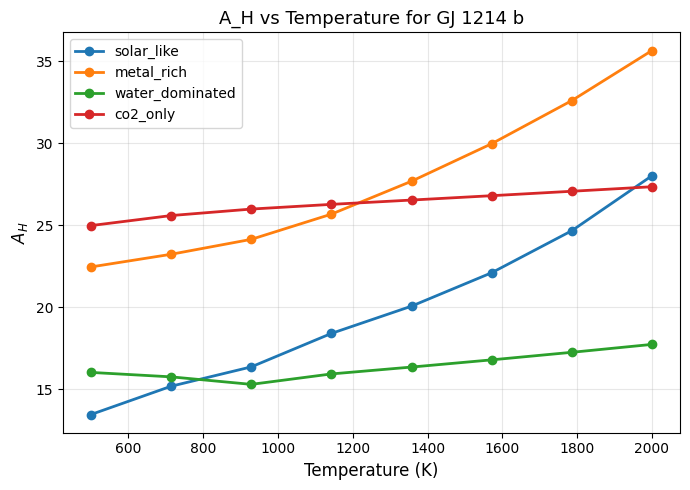

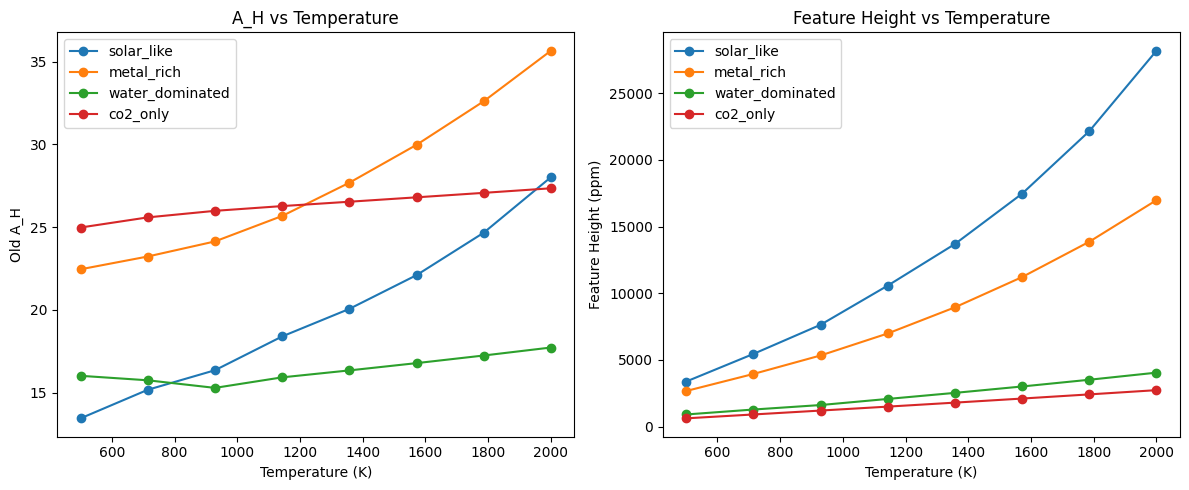

Elapsed time: 2.1619749069213867 seconds


In [10]:
import numpy as np
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import os
import time

# ===============================
# 1. Load Cross-Sections (once)
# ===============================

def load_cross_sections():

    base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))


    xsec_path = os.path.join(
        base_dir,
        'GivenResources',
        'cross_section_files',
        'Cross_section_files'
    )

    molecules = ['h2o', 'ch4', 'co', 'co2']

    xsec_dict = {}
    lam_dict = {}
    P_dict = {}
    T_dict = {}

    for mol in molecules:
        xsec_dict[mol] = np.load(os.path.join(xsec_path, f'{mol}_xsec.npy'))
        lam_dict[mol] = np.load(os.path.join(xsec_path, f'{mol}_lam.npy')) * 1e6
        P_dict[mol] = 10**np.load(os.path.join(xsec_path, f'{mol}_P.npy'))
        T_dict[mol] = np.load(os.path.join(xsec_path, f'{mol}_T.npy'))

    xsec_h2h2 = np.load(os.path.join(xsec_path, 'h2_h2_xsec.npy'))
    lam_h2h2 = np.load(os.path.join(xsec_path, 'h2_h2_lam.npy'))

    xsec_heh2 = np.load(os.path.join(xsec_path, 'he_h2_xsec.npy'))
    lam_heh2 = np.load(os.path.join(xsec_path, 'he_h2_lam.npy'))

    return xsec_dict, lam_dict, P_dict, T_dict, xsec_h2h2, lam_h2h2, xsec_heh2, lam_heh2



# ===============================
# 2. Composition Definitions
# values are the indicies of the log10(mixing ratio) for each molecule, ie. logX['h2o'] = -3 means X_h2o = 10^-3
# ===============================

def get_composition(comp_type):

    if comp_type == "solar_like":
        logX = {'h2o': -3.0, 'ch4': -5.0, 'co': -4.0, 'co2': -6.0}

    elif comp_type == "metal_rich":
        logX = {'h2o': -1.1, 'ch4': -1.74, 'co': -2.0, 'co2': -1.7}

    elif comp_type == "water_dominated":
        logX = {'h2o': -0.3, 'ch4': -6.0, 'co': -6.0, 'co2': -6.0}

    elif comp_type == "co2_only":
        logX = {'h2o': -12.0, 'ch4': -12.0, 'co': -12.0, 'co2': -0.3}

    return logX


# ===============================
# 3. Mean Molecular Weight
# ===============================

def compute_mu(logX, pure_steam=False):

    mmw = {
        'h2o': 18.0,
        'ch4': 16.0,
        'co': 28.0,
        'co2': 44.0,
        'h2': 2.0,
        'he': 4.0
    }

    if pure_steam:
        mu = 0.0
        for mol in logX:
            mu += 10**logX[mol] * mmw[mol]
        return mu * sc.u, logX

    X_rest = np.sum([10**logX[m] for m in logX])
    X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
    X_He = 0.17 * X_H2

    logX['h2'] = np.log10(X_H2)
    logX['he'] = np.log10(X_He)

    mu = 0.0
    for mol in logX:
        mu += 10**logX[mol] * mmw[mol]

    return mu * sc.u, logX


# ===============================
# 4. Atmosphere Builder
# ===============================

def build_atmosphere(Tp, mu, Rp, Mp, Pref):

    P = np.logspace(2.0, -9, 100) * 1e5
    T = Tp * np.ones_like(P)

    gp = (sc.G * Mp) / (Rp)**2

    r = np.zeros_like(P)
    g = np.zeros_like(P)

    i_Rp = np.argmin(np.abs(P - Pref))
    r[i_Rp] = Rp
    g[i_Rp] = gp

    for i in range(i_Rp + 1, len(P)):
        g[i] = g[i_Rp] * r[i_Rp]**2 / r[i-1]**2
        H_local = sc.k * Tp / (mu * g[i])
        delta_r = H_local * np.log(P[i-1] / P[i])
        delta_r = np.clip(delta_r, -5e6, 5e6)
        r[i] = r[i-1] + delta_r
        # if r[i] > Rp * 1.5:
        #     r[i] = Rp * 1.5


    for i in range(i_Rp - 1, -1, -1):
        g[i] = g[i_Rp] * r[i_Rp]**2 / r[i+1]**2
        H_local = sc.k * Tp / (mu * g[i])
        delta_r = H_local * np.log(P[i+1] / P[i])
        delta_r = np.clip(delta_r, -5e6, 5e6)
        r[i] = r[i+1] + delta_r
        # if r[i] > Rp * 1.5:
        #     r[i] = Rp * 1.5


    n = P / (sc.k * T)

    return P, T, r, g, gp, n


# ===============================
# 5. Transmission Spectrum
# ===============================

def compute_transmission_spectrum(
        Tp, logX, Rp, Rs, P, T, r, n,
        xsec_dict, lam_dict, P_dict, T_dict,
        xsec_h2h2, lam_h2h2,
        xsec_heh2, lam_heh2):

    lam = np.linspace(0.61, 5.0, 200) #might need to increase number of points, i.e. 200 to 1000

    log_xsec_dict = {}

    for mol in ['h2o', 'ch4', 'co', 'co2']:

        interp = RegularGridInterpolator(
            (lam_dict[mol], P_dict[mol], T_dict[mol]),
            xsec_dict[mol],
            bounds_error=False,
            fill_value=None
        )

        lamlam, PP = np.meshgrid(lam, P, indexing="ij")
        T0 = np.clip(T[0], T_dict[mol].min(), T_dict[mol].max())
        pts = np.vstack((lamlam.ravel(), PP.ravel(), np.full(lamlam.size, T0))).T

        log_xsec_dict[mol] = interp(pts).reshape(lamlam.shape)

    log_cia_h2h2 = np.interp(lam, lam_h2h2, xsec_h2h2)
    log_cia_heh2 = np.interp(lam, lam_heh2, xsec_heh2)

    sum_nsigma = np.zeros((len(lam), len(P)))

    for mol in log_xsec_dict:
        sum_nsigma += n[np.newaxis, :] * 10**logX[mol] * 10**log_xsec_dict[mol]

    #sum_nsigma += n[np.newaxis,:]**2 * 10**logX['h2']**2 * 10**log_cia_h2h2[:,None]
    #sum_nsigma += n[np.newaxis,:]**2 * 10**logX['he'] * 10**logX['h2'] * 10**log_cia_heh2[:,None]
    # --- CIA Contributions (only if species exist) ---

    if 'h2' in logX:
        sum_nsigma += (
            n[np.newaxis,:]**2
            * 10**logX['h2']**2
            * 10**log_cia_h2h2[:,None]
        )

    if 'h2' in logX and 'he' in logX:
        sum_nsigma += (
            n[np.newaxis,:]**2
            * 10**logX['he']
            * 10**logX['h2']
            * 10**log_cia_heh2[:,None]
        )



    integral_gt_Rp = np.zeros(len(lam))
    integral_lt_Rp = np.zeros(len(lam))
    exptau = np.zeros((len(P), len(lam)))

    for i in range(len(r)-1):

        s_tot = np.sqrt(r[i:]**2 - r[i]**2)
        ds = s_tot[1:] - s_tot[:-1]

        tau = np.sum((sum_nsigma[:, i:-1] + sum_nsigma[:, i+1:]) * ds[np.newaxis,:], axis=-1)
        exptau[i, :] = np.exp(-tau) + 1e-250

    for i in range(len(r)-1):

        if r[i] >= Rp:
            integral_gt_Rp += 0.5*((r[i]*(1-exptau[i]) +
                                    r[i+1]*(1-exptau[i+1]))*(r[i+1]-r[i]))

        if r[i] < Rp:
            integral_lt_Rp += 0.5*((r[i]*exptau[i] +
                                    r[i+1]*exptau[i+1])*(r[i+1]-r[i]))

    transit_depth = (Rp**2 + 2*integral_gt_Rp - 2*integral_lt_Rp)/(Rs**2)

    return lam, transit_depth


# ===============================
# 6. A_H Metric
# ===============================

def compute_AH(transit_depth, Tp, mu, Rp, Rs, gp):

    H = sc.k * Tp / (mu * gp)
    delta_D = np.max(transit_depth) - np.min(transit_depth)
    AH = delta_D / (2 * H * Rp / (Rs**2))

    return AH

def compute_feature_height(R_lambda, R_star):

    transit_depth = (R_lambda / R_star)**2
    delta_D = np.max(transit_depth) - np.min(transit_depth)

    return delta_D


# ===============================
# 7. Experiment Controller
# ===============================

def run_experiment():

    # Choose ONE planet manually for experiment - GJ 1214 b
    Rp = 2.733 * const.R_earth.value
    Mp = 8.41 * const.M_earth.value
    Rs = 0.2162 * const.R_sun.value 
    Pref = 1e5 #reference pressure for radius definition

    temperature_grid = np.linspace(500, 2000, 8)
    composition_types = ["solar_like", "metal_rich", "water_dominated", "co2_only"]

    xsec_data = load_cross_sections()

    AH_results = {c: [] for c in composition_types}
    feature_results = {c: [] for c in composition_types}

    for comp in composition_types:
        for Tp in temperature_grid:
            
            logX = get_composition(comp)
            mu, logX = compute_mu(logX)

            P, T, r, g, gp, n = build_atmosphere(Tp, mu, Rp, Mp, Pref)

            lam, transit_depth = compute_transmission_spectrum(
                Tp, logX, Rp, Rs, P, T, r, n,
                *xsec_data
            )

            AH = compute_AH(transit_depth, Tp, mu, Rp, Rs, gp)
            AH_results[comp].append(AH)
            
            delta_D = (np.max(transit_depth) - np.min(transit_depth)) * 1e6
            feature_results[comp].append(delta_D)

            print(f"{comp} | T={Tp:.0f}K | A_H={AH:.3f} | dD={delta_D:.1f} ppm")


    
    # ==========================================
    # Intermittent Plot: A_H vs Temperature
    # For GJ 1214 b only
    # ==========================================

    plt.figure(figsize=(7,5))

    for comp in composition_types:
        plt.plot(
            temperature_grid,
            AH_results[comp],
            marker='o',
            linewidth=2,
            label=comp
        )

    plt.xlabel("Temperature (K)", fontsize=12)
    plt.ylabel(r"$A_H$", fontsize=12)
    plt.title("A_H vs Temperature for GJ 1214 b", fontsize=13)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    
    
    
    
    plt.figure(figsize=(12,5))

    # ---- Left Panel: A_H ----
    plt.subplot(1, 2, 1)

    for comp in composition_types:
        plt.plot(temperature_grid, AH_results[comp], marker='o', label=comp)

    plt.xlabel("Temperature (K)")
    plt.ylabel("Old A_H")
    plt.title("A_H vs Temperature")
    plt.legend()


    # ---- Right Panel: Feature Height ----
    plt.subplot(1, 2, 2)

    for comp in composition_types:
        plt.plot(temperature_grid, feature_results[comp], marker='o', label=comp)

    plt.xlabel("Temperature (K)")
    plt.ylabel("Feature Height (ppm)")
    plt.title("Feature Height vs Temperature")
    plt.legend()


    plt.tight_layout()
    plt.show()



# ===============================
# MAIN
# ===============================

if __name__ == "__main__":
    start = time.time()
    run_experiment()
    print("Elapsed time:", time.time() - start, "seconds")
